## Module_3: Idiopathic Pulmonary Fibrosis

## Team Members:
Lauren Kim and Dani Folks

## Project Title:
Utilizing Computational Modes of Interpolation to Predict Percentage of Scarred Tissue in Patients with Idiopathic Pulmonary Fibrosis



## Project Goal:
This project seeks to utilize the computational method of interpolation to predict the percentage of scarred tissue at a specified depth in microns from patients with idiopathic pulmonary fibrosis. 

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analyis: 
*1.1 -- Image Selection*

A total of 6 images were randonmly selected from an unpublished dataset compiled by the Peirce-Cottler Lab and Kim Lab at the University of Virginia School of Medicine. Each image contains its corresponding label that indicate the region of imaging. 


*1.2 -- Coding Methodology*

The first step was to load 12 different pulmonary fibrosis images and create a list of corresponding depths in microns in the order that the images were listed.

In [2]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd

#AI STATEMENT: AI was utilized to generate a more efficient code up to line 93. 

# Load 12 different images for analysis
filenames = [
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010092.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010126.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010159.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010066.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010030.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010168.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010039.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010021.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010017.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010036.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010019.jpg",
    r"C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Llobe ch010022.jpg",
    
]

# Enter the corresponding depth of each image (in the same order that the images are listed above)

depths = [
    1000,
    6800,
    860,
    1000,
    200,
    6000,
    15,
    30,
    45,
    55,
    60,
    80
]

Next, empty lists were created for each variable (images, white_counts, black_counts, and white_percents) in order to utilize for loops to append items to relevant lists and calculate the percentage of white pixels. Below this code cell displays the printed outputs of each image and contains black and white pixel count as well as the image, relevant imaging depth in microns and calculated white pixel percentage.

In [3]:
# Create lists for white pixel percentage calculations

images = []
white_counts = []
black_counts = []
white_percents = []

# Build the list of all the images used for analysis

for filename in filenames:
    img = cv2.imread(filename, 0)
    images.append(img)

# For each image (until the end of the list of images), calculate the number of black and white pixels and make a list that contains this information for each filename.

for x in range(len(filenames)):
    _, binary = cv2.threshold(images[x], 127, 255, cv2.THRESH_BINARY)

    white = np.count_nonzero(binary == 255)
    black = binary.size - white

    white_counts.append(white)
    black_counts.append(black)

# Print the number of white and black pixels in each image.

print(colored("Counts of pixel by color in each image", "yellow"))
for x in range(len(filenames)):
    print(colored(f"White pixels in image {x}: {white_counts[x]}", "white"))
    print(colored(f"Black pixels in image {x}: {black_counts[x]}", "black"))
    print()

# Calculate the percentage of pixels in each image that are white and make a list that contains these percentages for each filename

for x in range(len(filenames)):
    white_percent = (
        100 * (white_counts[x] / (black_counts[x] + white_counts[x])))
    white_percents.append(white_percent)

# Print the filename (on one line in red font), and below that line print the percent white pixels and depth into the lung where the image was obtained

print(colored("Percent white pixel:", "yellow"))
for x in range(len(filenames)):
    print(colored(f'{filenames[x]}:', "red"))
    print(f'{white_percents[x]}% White | Depth: {depths[x]} microns')
    print()

Counts of pixel by color in each image
White pixels in image 0: 328891
Black pixels in image 0: 3865413

White pixels in image 1: 102335
Black pixels in image 1: 4091969

White pixels in image 2: 59426
Black pixels in image 2: 4134878

White pixels in image 3: 60715
Black pixels in image 3: 4133589

White pixels in image 4: 37799
Black pixels in image 4: 4156505

White pixels in image 5: 99350
Black pixels in image 5: 4094954

White pixels in image 6: 21648
Black pixels in image 6: 4172656

White pixels in image 7: 23900
Black pixels in image 7: 4170404

White pixels in image 8: 27561
Black pixels in image 8: 4166743

White pixels in image 9: 29677
Black pixels in image 9: 4164627

White pixels in image 10: 31331
Black pixels in image 10: 4162973

White pixels in image 11: 33151
Black pixels in image 11: 4161153

Percent white pixel:
C:/Users/crown/OneDrive\Desktop/Comp_BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010092.jpg:
7.841372489929199% White | Depth: 1000 microns

C:/Users/

In order to save this newly processed data, a csv file containing information relevant to only the 12 images selected was created utilizing a function based on the Boolean relationship index = False. 

In [5]:

# Create a DataFrame that includes the filenames, depths, and percentage of white pixels
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# Write that DataFrame to a .csv file

df.to_csv('Percent_White_Pixels.csv', index=False)

# Print confirmation statement to ensure that csv file has been made.
print("The .csv file 'Percent_White_Pixels.csv' has been created.")

The .csv file 'Percent_White_Pixels.csv' has been created.


The next step was to create an index for the the interpolated point based on the linear model. Based on the scatter plot of known white pixel percentages, the trend displayed a highly linear relationship. Due to this the linear mode of interpolation was selected for our particular dataset. The quadratic was performed; however, an error prohibited use of the quadratic mode. Our hypothesis is that with the distribution of our data, a parabola was forming, where there were two same y-values for separate x-values, as indicated by the terminal. Due to this, the function was unable to select interpolate a point for a given depth input due to a duplicate output at a different depth. scipy.interpolate library also bears a limitation (as noted by Google Gemini) where it assumes a strictly monotonic dataset. Thus, a duplicate output would render the quadratic mode of interpolation unusable. 

In [6]:
# Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
    "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# Interpolate utilizing a linear model and create an interactive element that enables the user to input the desired micron depth and recieve a predicted percentage of scarred tissue (white pixels)
i = interp1d(x, y, kind='linear')
interpolate_point = i(interpolate_depth)
print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)

The interpolated point is at the x-coordinate 800.0 and y-coordinate 1.36995098807595.


*1.3 -- Graphs and Plots*

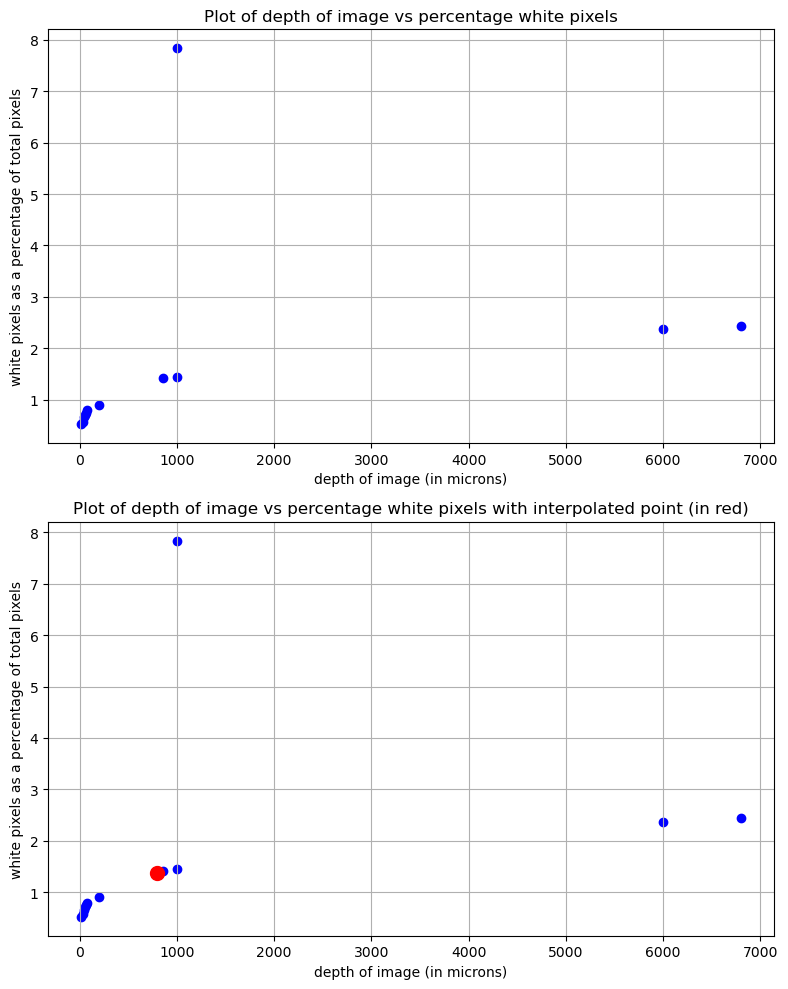

In [14]:
# make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
# AI Usage Statement: For the line of code directly below, Google Gemini was utilized to learn how to better size the graphs to prevent overlap of axes titles. 
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
               linestyle='-', color='blue')
axs[1].set_title(
    'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
               color='red', s=100, label='Highlighted point')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*